# Introduction to NumPy, Pandas, and Probability Basics

This notebook provides a straightforward introduction to:
1. **NumPy Basics**: Creating arrays, slicing, reshaping, boolean masking, and performing element-wise operations.
2. **Pandas & Data Visualization**: Handling missing data, generating summary statistics, filtering, grouping, and plotting.
3. **Probability & Distributions**: Simulating coin flips/dice rolls and generating normal distributions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. NumPy Basics

NumPy is used for efficient numerical computing. Here we cover array creation, slicing, reshaping, masking, and basic math.

In [2]:
# Create 1D and 2D arrays
arr_1d = np.array([10, 20, 30, 40, 50, 60])
arr_2d = np.array([[1, 2, 3], [4, 5, 6]])

print("1D Array:", arr_1d)
print("2D Array:\n", arr_2d)

# Slicing and indexing
print("First 3 elements of 1D array:", arr_1d[:3])
print("Element at row 1, col 2 of 2D array:", arr_2d[1, 2])

# Reshaping: Transform 1D array (6 elements) to 2D (2 rows, 3 columns)
reshaped_arr = arr_1d.reshape(2, 3)
print("\nReshaped Array (2x3):\n", reshaped_arr)

# Boolean masking: Filter elements greater than 35
mask = arr_1d > 35
filtered_arr = arr_1d[mask]
print("\nBoolean Mask (arr_1d > 35):", mask)
print("Filtered Array:", filtered_arr)

# Basic math operations
print("\nMean of 1D array:", arr_1d.mean())
print("Sum of 2D array columns:", arr_2d.sum(axis=0))

1D Array: [10 20 30 40 50 60]
2D Array:
 [[1 2 3]
 [4 5 6]]
First 3 elements of 1D array: [10 20 30]
Element at row 1, col 2 of 2D array: 6

Reshaped Array (2x3):
 [[10 20 30]
 [40 50 60]]

Boolean Mask (arr_1d > 35): [False False False  True  True  True]
Filtered Array: [40 50 60]

Mean of 1D array: 35.0
Sum of 2D array columns: [5 7 9]


## 2. Pandas & Data Visualization

Pandas structures data into DataFrames, making manipulation, cleaning, and plotting simple.

In [3]:
# Create a simple dataset of student grades with missing values (NaN)
data = {
    'Student': ['Alice', 'Bob', 'Charlie', 'David', 'Eva', 'Frank'],
    'Major': ['CS', 'Math', 'CS', 'Physics', 'Math', 'CS'],
    'Grade': [88.0, 92.0, np.nan, 95.0, 85.0, np.nan],
    'StudyHours': [12.0, 15.0, 8.0, np.nan, 11.0, 14.0]
}

df = pd.DataFrame(data)
df

,Student,Major,Grade,StudyHours
0,Alice,CS,88.0,12.0
1,Bob,Math,92.0,15.0
2,Charlie,CS,NaN,8.0
3,David,Physics,95.0,NaN
4,Eva,Math,85.0,11.0
5,Frank,CS,NaN,14.0


In [4]:
# Descriptive summary statistics
print("Summary Statistics:\n", df.describe())

Summary Statistics:
            Grade  StudyHours
count   4.000000    5.000000
mean   90.000000   12.000000
std     4.396969    2.738613
min    85.000000    8.000000
25%    87.250000   11.000000
50%    90.000000   12.000000
75%    92.750000   14.000000
max    95.000000   15.000000


In [5]:
# Check for missing values
print("Missing values per column:\n", df.isna().sum())

# Data cleaning: Fill missing Grades with the column mean, and drop rows with missing StudyHours
df_clean = df.copy()
df_clean['Grade'] = df_clean['Grade'].fillna(df_clean['Grade'].mean())
df_clean = df_clean.dropna(subset=['StudyHours'])

df_clean

Missing values per column:
 Student       0
Major         0
Grade         2
StudyHours    1
dtype: int64


,Student,Major,Grade,StudyHours
0,Alice,CS,88.0,12.0
1,Bob,Math,92.0,15.0
2,Charlie,CS,90.0,8.0
4,Eva,Math,85.0,11.0
5,Frank,CS,90.0,14.0


In [6]:
# Filter students with grade > 85
high_achievers = df_clean[df_clean['Grade'] > 85]
print("Students with Grade > 85:\n", high_achievers)

# Group by Major and calculate the average Grade
average_by_major = df_clean.groupby('Major')['Grade'].mean()
print("\nAverage Grade by Major:\n", average_by_major)

Students with Grade > 85:
    Student Major  Grade  StudyHours
0    Alice    CS   88.0        12.0
1      Bob  Math   92.0        15.0
2  Charlie    CS   90.0         8.0
5    Frank    CS   90.0        14.0

Average Grade by Major:
 Major
CS      89.333333
Math    88.500000
Name: Grade, dtype: float64


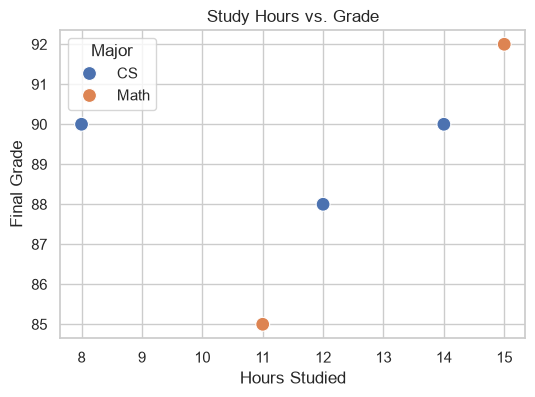

In [7]:
# Scatter plot showing correlation between study hours and grade
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_clean, x='StudyHours', y='Grade', hue='Major', s=100)
plt.title('Study Hours vs. Grade')
plt.xlabel('Hours Studied')
plt.ylabel('Final Grade')
plt.show()

## 3. Probability & Distributions

Here we simulate random events and visualize standard distributions.

### 3.1 Simulating Dice Rolls (Discrete Probability)

We simulate rolling a fair 6-sided die 1000 times to see how the frequency matches the expected probability (1/6 ≈ 0.167 for each face).

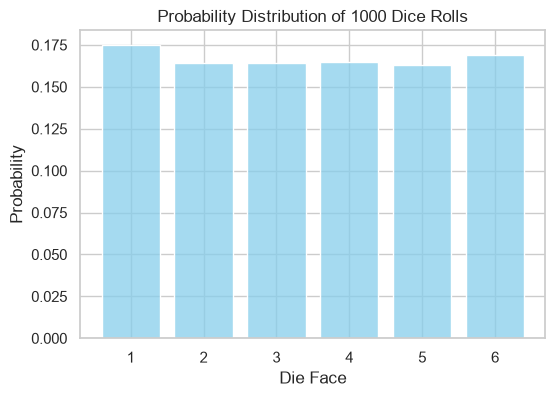

In [8]:
# Simulate 1000 rolls of a 6-sided die
rolls = np.random.randint(1, 7, size=1000)

# Plot the distribution of outcomes
plt.figure(figsize=(6, 4))
sns.histplot(rolls, discrete=True, stat='probability', color='skyblue', shrink=0.8)
plt.title('Probability Distribution of 1000 Dice Rolls')
plt.xlabel('Die Face')
plt.ylabel('Probability')
plt.xticks(range(1, 7))
plt.show()

### 3.2 Normal Distribution (Continuous Probability)

Generating random samples from a Normal distribution and plotting the density curve.

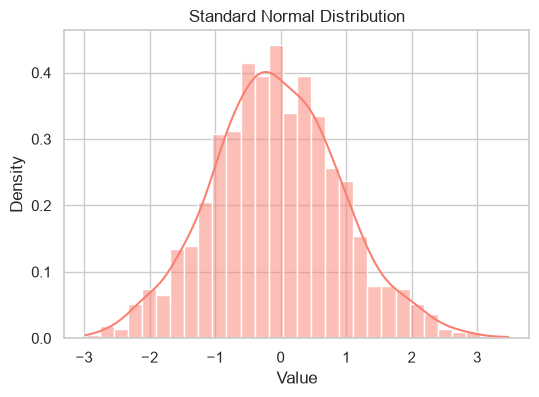

In [9]:
# Sample 1000 values from a standard normal distribution
normal_samples = np.random.normal(loc=0, scale=1, size=1000)

# Plot histogram with a smooth density curve (KDE)
plt.figure(figsize=(6, 4))
sns.histplot(normal_samples, kde=True, stat='density', color='salmon', bins=30)
plt.title('Standard Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()